# Readme

Plot responses by type.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np

In [2]:
from eyewire2_functional_analysis import data_loader

data_folder = "../../data/preprocessed-data"
nuc_col_master='Updated Nuc ID (Sept 2)'
seg_col_master='Updated Seg ID (Sept 2)'

#df_rois = data_loader.load_df_rois(data_folder)
df_merged = data_loader.load_df_rois_morph(
    morph_folder="../../data/morphological-data",
    data_folder="../../data/preprocessed-data",
    nuc_col_master=nuc_col_master,
    seg_col_master=seg_col_master,
)

# Plot function

In [3]:
def plot_mean_and_sd(ax, traces, time, color='black', alt_color='dimgray', facealpha=0.2, offset=0.0):
    if traces.shape[0] <= 2:
        ax.plot(time, traces[0] - np.mean(traces[0]) + offset, color=color)
        if len(traces) == 2:
            ax.plot(time, traces[1] - np.mean(traces[1]) + offset, color=alt_color)
    else:
        mu = np.mean(traces, axis=0)
        mu = mu - np.mean(mu) + offset
        sd = np.std(traces, axis=0)

        ax.plot(time, mu, color=color)
        ax.fill_between(time, mu - sd, mu + sd, color=color, alpha=facealpha)

In [6]:
swc_dir = 'X:/SharedFiles/Eyewire2/morphologies-ew2/c6fb66deed2b53502e41fdcec0caa3b9'
swc_files = [f for f in os.listdir(swc_dir) if f.endswith('.swc')]

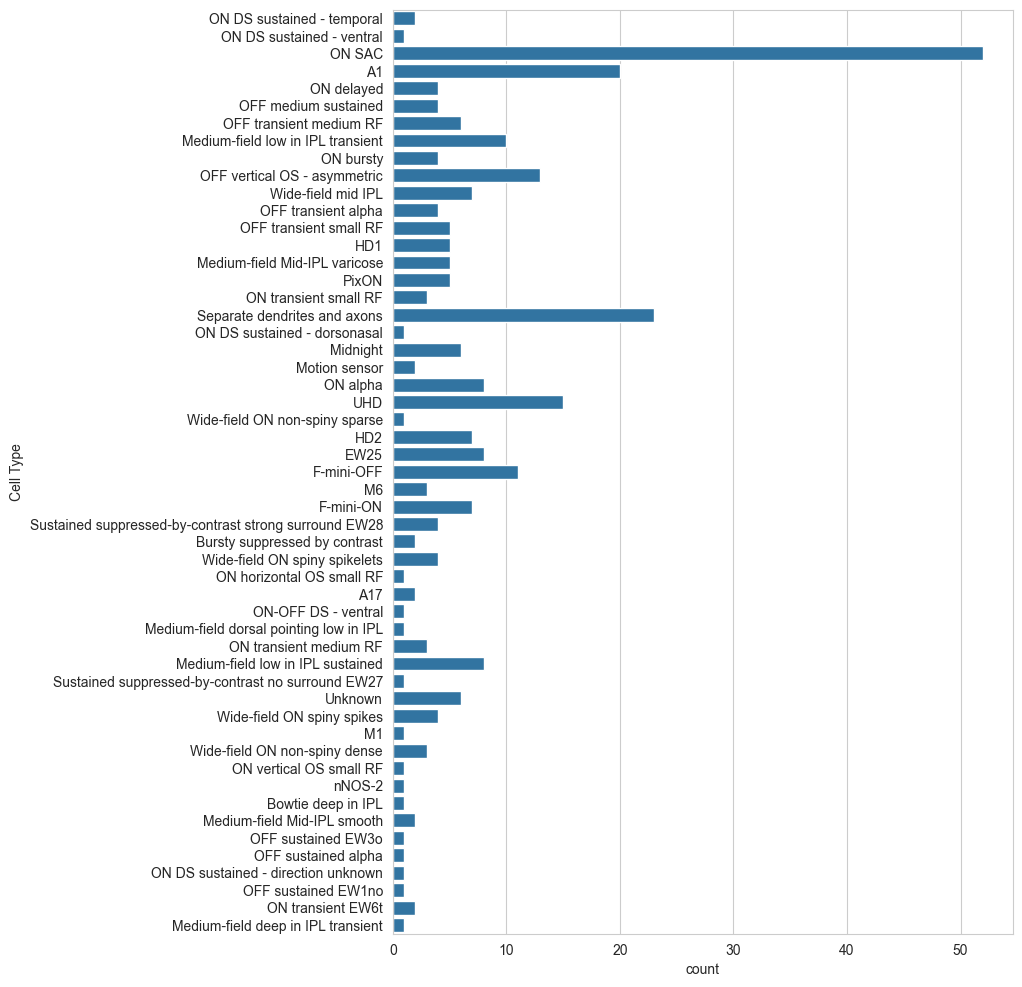

In [9]:
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(8, 12))
sns.countplot(ax=ax, data=df_merged, y='Cell Type')
plt.show()

In [11]:
t_chirp = np.arange(df_merged.chirp_average_norm.iloc[0].size) * df_merged.chirp_average_dt.iloc[0]
t_bar = np.arange(df_merged.bar_time_component.iloc[0].size) * df_merged.bar_snippets_dt.iloc[0]

In [ ]:
import skeliner as sk

In [ ]:
from eyewire2_functional_analysis.plot import plot_chirp, plot_bar

In [ ]:
def add_skels(df):
    df = df.copy()

    df['swc_path'] = df[seg_col_master].apply(lambda x: os.path.join(swc_dir, f"{x}.swc"))
    df['swc_exists'] = df['swc_path'].apply(lambda x: os.path.isfile(x))
    if np.any(~df['swc_exists']):
        print('SWC not found:', df[~df['swc_exists']].swc_path)
    df = df[df['swc_exists']]
    df['skel'] = df['swc_path'].apply(lambda x: sk.io.load_swc(x))
    return df

def plot_cells(df):
    assert df.shape[0] > 0, "No data to plot"
    df = add_skels(df)

    fig, axs = plt.subplots(len(df), 4, figsize=(8, len(df) * 1.2), width_ratios=(1, 2, 2, 1))

    for i, ax_to_replace in enumerate(axs[:, -1]):
        ax_to_replace.remove()
        polar_ax = fig.add_subplot(ax_to_replace.get_subplotspec(), polar=True)
        axs[i, -1] = polar_ax

    for i, (seg_id, row) in enumerate(df.iterrows()):
        plot_morph(ax=axs[i, 0], row=row)
        plot_chirp(ax=axs[i, 1], row=row)
        plot_bar(ax=axs[i, 2], row=row, annotate_dirs=i == 0)
        plot_bar_dir(ax=axs[i, 3], row=row)

    for ax in axs[:, :-1].flat:
        ax.set(xlabel=None, ylabel=None, xticks=[], yticks=[])
        ax.axis('off')

    for ax in axs[:, -1].flat:
        ax.set(xlabel=None, ylabel=None, xticks=np.deg2rad([0, 90, 180, 270]), yticks=[], ylim=(0, None))

    plt.tight_layout()
    return fig, axs

In [14]:
import cell_mosaics

def plot_mosaic(df, extent = (350, 1000, 0, 650)):
    assert df.shape[0] > 0, "No data to plot"
    df = add_skels(df)

    mapper = cell_mosaics.CoverageDensityMapper(field_bounds=extent, resolution=500)
    for i, (seg_id, row) in enumerate(df.iterrows()):
        mapper.add_convex_hull(row.skel.nodes[row.skel.nodes[:, 2] > -10, :2])
    fig, ax, im = mapper.plot_coverage(colormap='bone_r', plot_cell_outlines=True)
    for i, (seg_id, row) in enumerate(df.sample(1).iterrows()):
        plot_morph(ax=ax, row=row)
    ax.set(xlim=extent[:2], ylim=extent[2:])
    return fig, ax

In [15]:
fig2_dir = './figures/examples'
os.makedirs(fig2_dir, exist_ok=True)

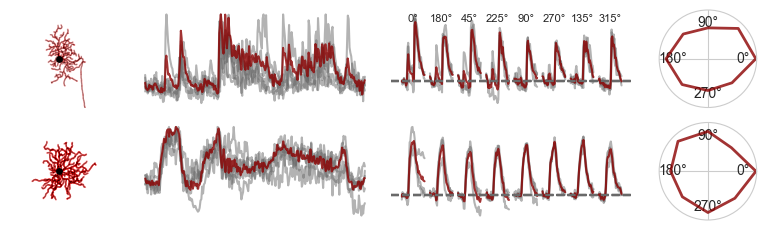

In [16]:
# For Sebastian
df_type = df_merged[
    (df_merged['roi_id'].astype(int).isin([62, 52]))
    & (df_merged["field"] == 'GCL2')
    ]
df_type = df_type.drop_duplicates(subset=[seg_col_master], keep='first')

fig, axs = plot_cells(df_type)
#plt.savefig(os.path.join(fig2_dir, 'examples_GCL2_52_62.eps'))
plt.show()

[720575940563265819 720575940572551485 720575940576369093
 720575940562015742 720575940546061452 720575940583667923
 720575940551647474 720575940547919816 720575940576381125
 720575940561194713 720575940579488144 720575940560950763]


,Updated Seg ID (Sept 2),Cell Type,Machine label
45,720575940563265819,UHD,5ti
50,720575940572551485,UHD,5ti
54,720575940576369093,UHD,5ti
90,720575940562015742,UHD,5ti
96,720575940546061452,UHD,5ti
105,720575940583667923,UHD,5ti
151,720575940551647474,UHD,5ti
164,720575940547919816,UHD,5ti
168,720575940576381125,UHD,5ti
186,720575940561194713,UHD,5ti


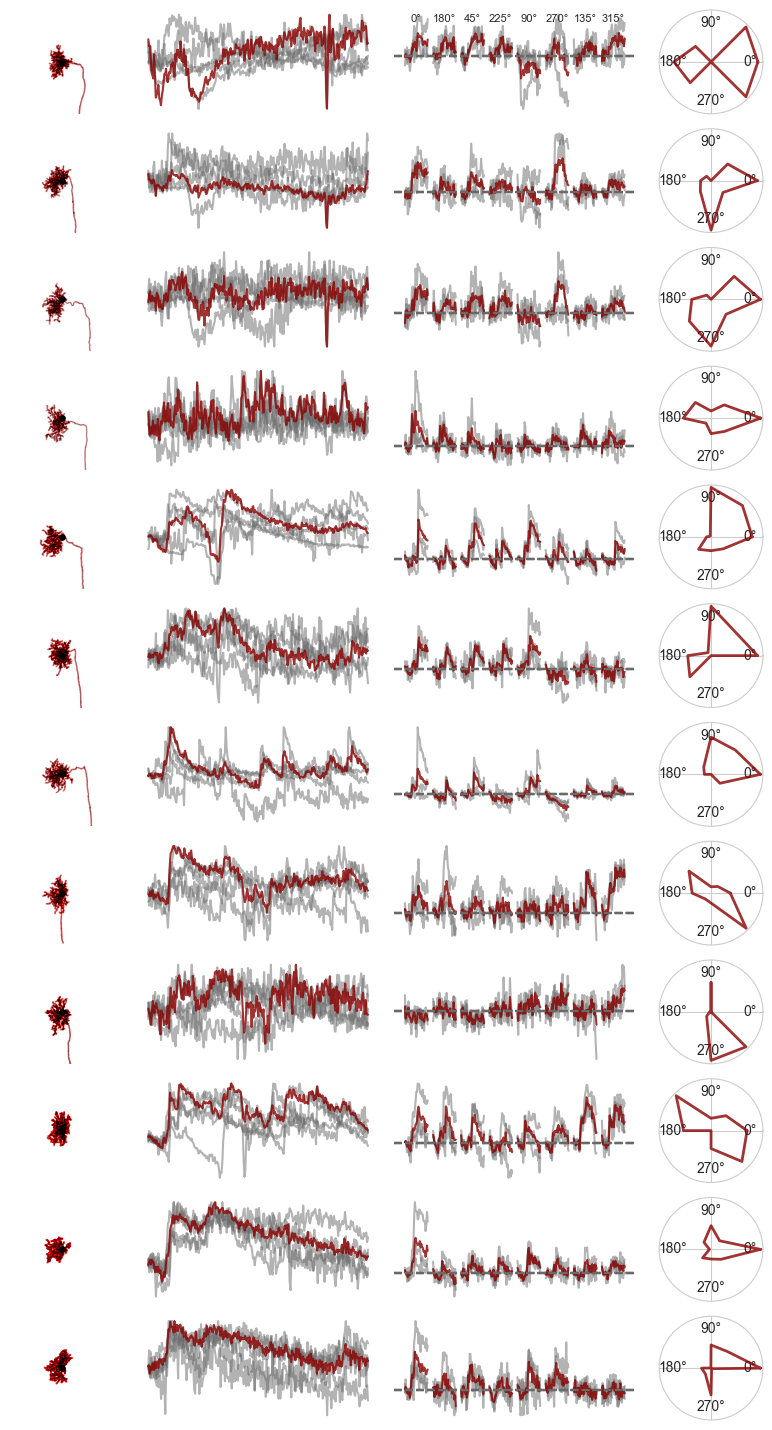

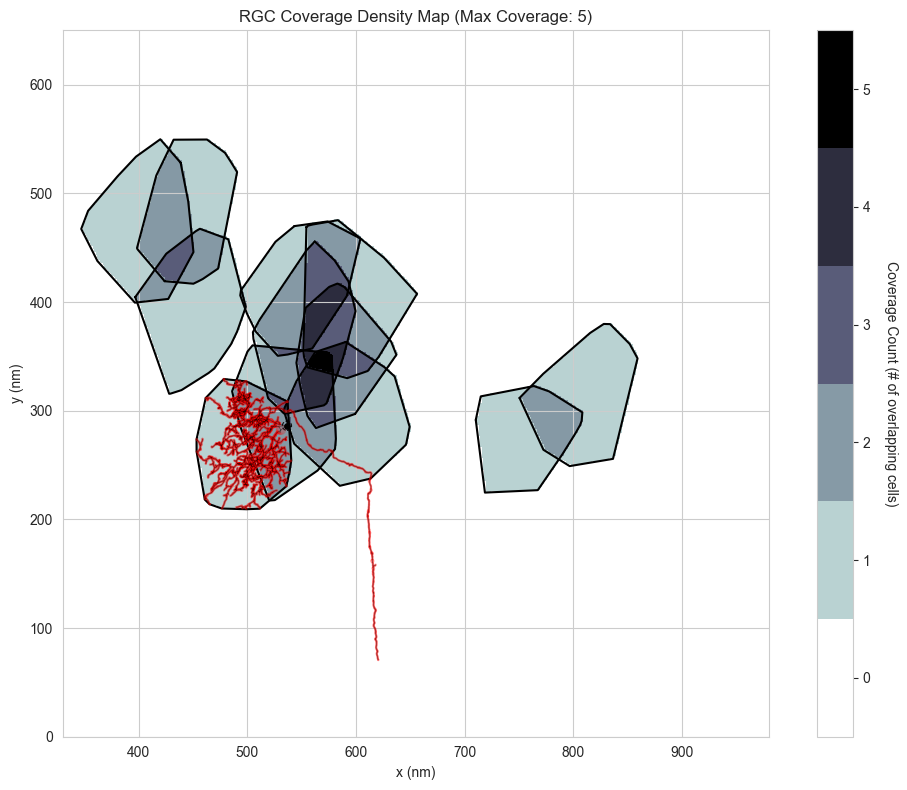

In [17]:
uhd_list = [720575940546061452, 720575940547919816, 720575940551647474, 720575940560950763, 720575940561194713,
            720575940562015742, 720575940563265819, 720575940572551485, 720575940576369093,
            720575940576381125, 720575940579488144, 720575940583667923]

df_type = df_merged[
    #((df_merged['Cell Type'] == 'UHD') | ((df_merged['Machine label'] == '5ti') & (df_merged['Confidence machine label'].astype(float) > 0.5)))
    (df_merged[seg_col_master].astype(int).isin(uhd_list))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')
    ]
df_type = df_type.drop_duplicates(subset=[seg_col_master], keep='first')

print(df_type[seg_col_master].values.astype(int))
display(df_type[[seg_col_master, 'Cell Type', 'Machine label']])

fig, axs = plot_cells(df_type)
#plt.savefig(os.path.join(fig2_dir, 'examples_uhd.pdf'))
plt.show()

fig, ax = plot_mosaic(df_type, extent = (330, 980, 0, 650))
#plt.savefig(os.path.join(fig2_dir, 'mosaic_uhd.pdf'))
plt.show()

[720575940563265819 720575940572551485 720575940576369093
 720575940562015742 720575940546061452 720575940583667923
 720575940551647474 720575940547919816 720575940576381125
 720575940561194713 720575940579488144 720575940560950763]


,Updated Seg ID (Sept 2),Cell Type,Machine label
45,720575940563265819,UHD,5ti
50,720575940572551485,UHD,5ti
54,720575940576369093,UHD,5ti
90,720575940562015742,UHD,5ti
96,720575940546061452,UHD,5ti
105,720575940583667923,UHD,5ti
151,720575940551647474,UHD,5ti
164,720575940547919816,UHD,5ti
168,720575940576381125,UHD,5ti
186,720575940561194713,UHD,5ti


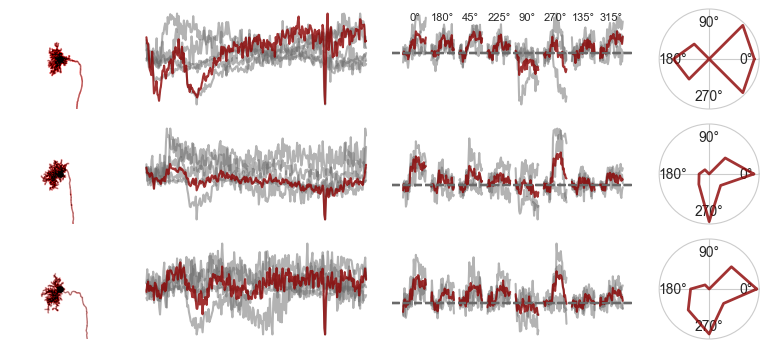

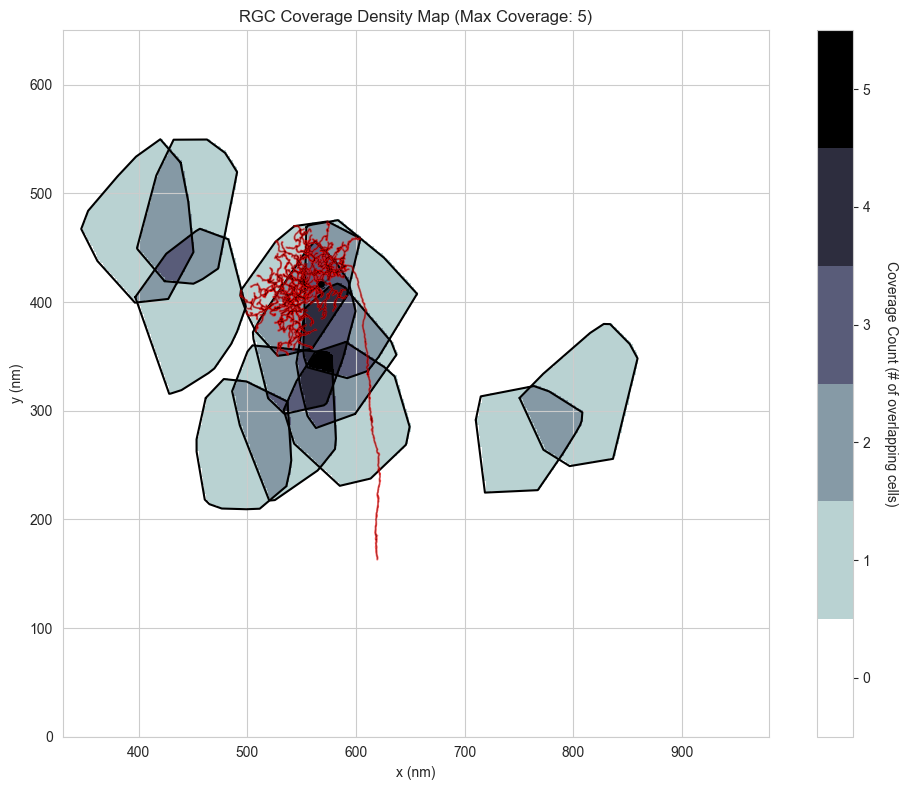

In [18]:
uhd_list = [720575940546061452, 720575940547919816, 720575940551647474, 720575940560950763, 720575940561194713,
            720575940562015742, 720575940563265819, 720575940572551485, 720575940576369093,
            720575940576381125, 720575940579488144, 720575940583667923]

df_type = df_merged[
    #((df_merged['Cell Type'] == 'UHD') | ((df_merged['Machine label'] == '5ti') & (df_merged['Confidence machine label'].astype(float) > 0.5)))
    (df_merged[seg_col_master].astype(int).isin(uhd_list))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')
    ]
df_type = df_type.drop_duplicates(subset=[seg_col_master], keep='first')

print(df_type[seg_col_master].values.astype(int))
display(df_type[[seg_col_master, 'Cell Type', 'Machine label']])

fig, axs = plot_cells(df_type.iloc[:3])
plt.savefig(os.path.join(fig2_dir, 'examples_uhd.png'), dpi=600)
plt.show()

fig, ax = plot_mosaic(df_type, extent = (330, 980, 0, 650))
plt.savefig(os.path.join(fig2_dir, 'mosaic_uhd.pdf'))
plt.show()

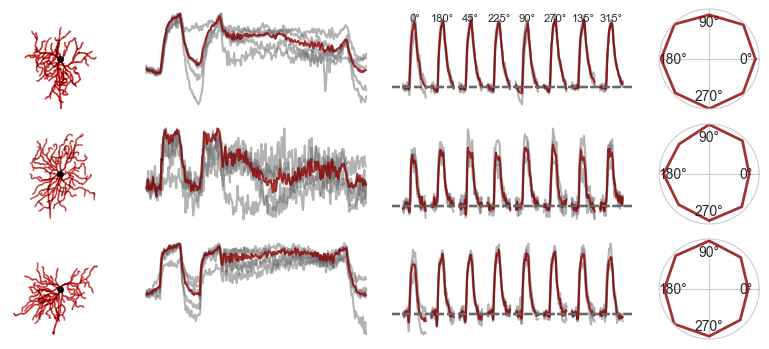

In [19]:
son_alpha_list = [720575940557469707, 720575940562911131, 720575940572157287, 720575940575066105]

df_type = df_merged[
    (df_merged[seg_col_master].astype(int).isin(son_alpha_list))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')
    ]

fig, axs = plot_cells(df_type.iloc[[0, 1, 3]])
plt.savefig(os.path.join(fig2_dir, 'examples_son_alphas.png'), dpi=600)

[720575940563567973 720575940576092590 720575940581355463
 720575940563588453]


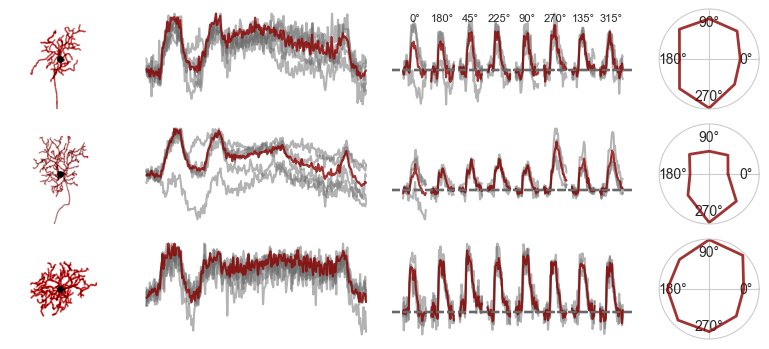

In [20]:
pixon_list = [720575940563567973, 720575940563588453, 720575940576092590, 720575940581355463]

df_type = df_merged[
    ((df_merged['Cell Type'] == 'PixON') | (
            (df_merged['Machine label'] == '9n') & (df_merged['Confidence machine label'].astype(float) > 0.5)))
    #(df_merged[seg_col_master].astype(int).isin(pixon_list))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')
    ]
df_type = df_type.drop_duplicates(subset=[seg_col_master], keep='first')

print(df_type[seg_col_master].values.astype(int))

fig, axs = plot_cells(df_type.iloc[[0, 1, 3]])
#plt.savefig(os.path.join(fig2_dir, 'examples_pixon.png'), dpi=600)

In [21]:
df_type.iloc[[0, 1, 3]]

,Updated Nuc ID (Sept 2),Index,Nuc Coords,Soma Coords,Cell Type (deprecated),611 Proofreader,Proofreader 2,Status,AIS annotated?,Final Link,...,cluster_id,group_id,supergroup,prob_cluster,prob_group,prob_supergroup,prob_class,probs_per_cluster,seg_id,nuc_id
31,720575940574221509,D30,"36884.0,20356.0,722.0","36884.0,20356.0,727.0",NaN,Elison,NaN,Complete,Annotated,https://spelunker.cave-explorer.org/#!middleau...,...,33,23,Slow ON,0.700664,0.700664,0.857186,0.919846,"[0.001954173609060556, 0.0018432415551910435, ...",720575940563567973,720575940574221509
42,720575940570684617,D39,"34836.0,25248.0,379.0","34836.0,25248.0,404.0",NaN,Rey Mark,NaN,Complete,Annotated,https://spelunker.cave-explorer.org/#!middleau...,...,65,42,dAC,0.516307,0.652191,0.747058,0.747058,"[0.0038852233741945644, 0.0032334072669986903,...",720575940576092590,720575940570684617
377,720575940569319349,D370,"51502.0,19497.0,965.0","51431.0,19511.0,994.0",NaN,Glenda,NaN,Complete,Annotated,https://spelunker.cave-explorer.org/#!middleau...,...,33,23,Slow ON,0.657267,0.657267,0.912382,0.957618,"[0.0013527515503129882, 0.001395631364001735, ...",720575940563588453,720575940569319349


# Finalize figure

In [22]:
import warnings
warnings.filterwarnings(
    "ignore",
    message=".*not compatible with tight_layout.*",
    category=UserWarning,
    module="matplotlib"
)

In [23]:
son_alpha_list = [720575940557469707, 720575940562911131, 720575940572157287, 720575940575066105]
df_type = df_merged[
    (df_merged[seg_col_master].astype(int).isin(son_alpha_list))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')]

df_son = df_type.iloc[[0, 1, 3]].copy()

In [24]:
pixon_list = [720575940563567973, 720575940563588453, 720575940576092590, 720575940581355463]
df_type = df_merged[
    ((df_merged['Cell Type'] == 'PixON') | (
            (df_merged['Machine label'] == '9n') & (df_merged['Confidence machine label'].astype(float) > 0.5)))
    #(df_merged[seg_col_master].astype(int).isin(pixon_list))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')
    ]
df_type = df_type.drop_duplicates(subset=[seg_col_master], keep='first')

df_pixon = df_type.iloc[[0, 1, 3]].copy()

In [25]:
uhd_list = [720575940546061452, 720575940547919816, 720575940551647474, 720575940560950763, 720575940561194713,
            720575940562015742, 720575940563265819, 720575940572551485, 720575940576369093,
            720575940576381125, 720575940579488144, 720575940583667923]

df_type = df_merged[
    #((df_merged['Cell Type'] == 'UHD') | ((df_merged['Machine label'] == '5ti') & (df_merged['Confidence machine label'].astype(float) > 0.5)))
    (df_merged[seg_col_master].astype(int).isin(uhd_list))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')
    ]
df_type = df_type.drop_duplicates(subset=[seg_col_master], keep='first')

df_uhd = df_type.iloc[[0, 1, 3]].copy()

In [ ]:
uhd_list = [720575940546061452, 720575940547919816, 720575940551647474, 720575940560950763, 720575940561194713,
            720575940562015742, 720575940563265819, 720575940572551485, 720575940576369093,
            720575940576381125, 720575940579488144, 720575940583667923]

df_type = df_merged[
    #((df_merged['Cell Type'] == 'UHD') | ((df_merged['Machine label'] == '5ti') & (df_merged['Confidence machine label'].astype(float) > 0.5)))
    (df_merged[seg_col_master].astype(int).isin(uhd_list))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')
    ]
df_type = df_type.drop_duplicates(subset=[seg_col_master], keep='first')

df_uhd = df_type.iloc[[0, 1, 3]].copy()

In [29]:
example_list = [720575940559143627]

df_type = df_merged[
    (df_merged[seg_col_master].astype(int).isin(example_list))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')
    ]
df_type = df_type.drop_duplicates(subset=[seg_col_master], keep='first')
df_example = df_type.copy()

In [28]:
# png_path = "C:/Users/Dominic Gonschorek/Documents/GitHub/eyewire2-functional-analysis/data/stimuli/chirp.png"   # <- change this
# chirp_img = plt.imread(png_path)
#
# png_path = "C:/Users/Dominic Gonschorek/Documents/GitHub/eyewire2-functional-analysis/data/stimuli/MB.png"   # <- change this
# mb_img = plt.imread(png_path)

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/Dominic Gonschorek/Documents/GitHub/eyewire2-functional-analysis/data/stimuli/chirp.png'

In [ ]:
from eyewire2_functional_analysis.plot import draw_scale_bar, plot_morph, plot_bar_dir
from matplotlib.transforms import Bbox

df = add_skels(df_pixon)

fig, axs = plt.subplots(
    len(df) + 1, 4,
    figsize=(8, (len(df) + 1) * 1.0),
    width_ratios=(1, 2, 2, 0.6), 
    gridspec_kw=dict(
        wspace=0.1, hspace=0.1,
        height_ratios=[0.35] + [1.0]*len(df)
    ),
)

for ax in axs[0, :]:
    ax.set_axis_off()

for r in range(1, len(df) + 1):
    gs = axs[r, -1].get_subplotspec()
    axs[r, -1].remove()
    axs[r, -1] = fig.add_subplot(gs, projection='polar')


for i, (seg_id, row) in enumerate(df.iterrows()):
    r = i + 1
    plot_morph(ax=axs[r, 0], row=row)
    plot_chirp(ax=axs[r, 1], row=row)
    plot_bar(ax=axs[r, 2], row=row, annotate_dirs=(i == 0))
    plot_bar_dir(ax=axs[r, 3], row=row)

for ax in axs[1:, :-1].flat:
    ax.set(xlabel=None, ylabel=None, xticks=[], yticks=[])
    ax.axis('off')

# format polar column
for ax in axs[1:, -1].flat:
    ax.set(xlabel=None, ylabel=None,
           xticks=np.deg2rad([0, 90, 180, 270]),
           yticks=[], ylim=(0, None))

#  add stimuli
ax = axs[0, 1]
ax.set_axis_off()
#chirp_zoom = 0.10   
#chirp_pos  = (0.5, 0.35)
#ab_chirp = AnnotationBbox(
#    OffsetImage(chirp_img, zoom=chirp_zoom, interpolation='nearest'),
#    chirp_pos, xycoords='axes fraction',
#    frameon=False, box_alignment=(0.5, 0.5))
#ax.add_artist(ab_chirp)
#axs[0,1].plot(chirp_stimulus, color='k',lw=1.5)

ax = axs[0, 2]
ax.set_axis_off()
mb_zoom = 0.08      
mb_pos  = (0.5, 0.7)
# ab_mb = AnnotationBbox(
#     OffsetImage(mb_img, zoom=mb_zoom, interpolation='nearest'),
#     mb_pos, xycoords='axes fraction',
#     frameon=False, box_alignment=(0.5, 0.5))
ax.add_artist(ab_mb)

# scale bar
draw_scale_bar(axs[3,0], length_data=200, label="200µm", where="lower center", y_frac=0.0)
draw_scale_bar(axs[3,1], length_data=2, label="2s", where="lower right", y_frac=0.0, x_pad_axes=0.045)
draw_scale_bar(axs[3,2], length_data=2, label="2s", where="lower right", y_frac=0.0, x_pad_axes=0.045)


# make chirp plots smaller in height
shrink_y = 0.75
y_shift = 0.0
targets = []
for r in (1, 2, 3):
    if r <= len(df):  # since row 0 is the header
        targets.append(axs[r, 1])
for ax in targets:
    box = ax.get_position()          # figure coordinates
    cx = 0.5 * (box.x0 + box.x1)
    cy = 0.5 * (box.y0 + box.y1)
    w  = box.width
    h  = box.height * shrink_y
    new_box = Bbox.from_bounds(cx - w/2, cy - h/2 + y_shift, w, h)
    ax.set_position(new_box)

plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0.0, hspace=0.0)

In [ ]:
import h5py

try:
    with h5py.File("Z:/Resources/Stimulus/chirp.h5", "r") as f:
        chirp_stimulus = f['stimulusarray'][:].T.astype(int)
    chirp_stimulus = np.append(chirp_stimulus, np.full(1000, chirp_stimulus[-1]))
except:
    chirp_stimulus = np.ones(32988).astype(int)

## sON alpha

In [ ]:
def plot_cell_v2(row):
    fig, ax = plt.subplot_mosaic(
        """
        XXXXXX
        AAAAAA
        BBBCDE
        BBBFGH
        BBBIJK
        """,
        figsize=(5, 4),
        gridspec_kw=dict(
            hspace=0.25, wspace=0.07, height_ratios=[0.4, 1, 1, 1, 1]),)

    plot_morph(ax=ax['B'], row=row)
    plot_chirp(ax=ax['A'], row=row)
    plot_bar_dir(ax=ax['G'], row=row)
    ax['G'].set(xlabel=None, ylabel=None, xticks=np.deg2rad([0, 90, 180, 270]), yticks=[], ylim=(0, None))


    MB_DIRS = (0, 180, 45, 225, 90, 270, 135, 315)  # your data order
    desired_deg = [0, 45, 90, 135, 180, 225, 270, 315]
    dir_idx_order = [MB_DIRS.index(d) for d in desired_deg]

    plot_bar_split(ax, row, labels=('C','D','E','F','H','I','J','K'), dir_idx_order=([6, 4, 2, 1, 0, 3, 5, 7]))

    gs = ax['G'].get_subplotspec()
    ax['G'].remove()
    ax['G'] = fig.add_subplot(gs, projection='polar')
    plot_bar_dir(ax=ax['G'], row=row)
    ax['G'].set(xlabel=None, ylabel=None, xticks=np.deg2rad([0, 90, 180, 270]), yticks=[], ylim=(0, None))

    ax['X'].plot(chirp_stimulus, color='k',lw=1.5)

    # remove axes
    for i in ['A','B','C','D','E','F','H','I','J','K','X']:
        ax[i].set(xlabel=None, ylabel=None, xticks=[], yticks=[])
        ax[i].axis('off')

    # scale bar
    draw_scale_bar(ax['B'], length_data=200, label="200µm", where="lower center", y_frac=0.01)
    draw_scale_bar(ax['A'], length_data=2, label="2s", where="lower left", y_frac=0.06, x_pad_axes=0.045)
    draw_scale_bar(ax['K'], length_data=2, label="2s", where="lower right", y_frac=0.06, x_pad_axes=0.045)
    #ax['B'].set_ylim(70,400)

C:\Users\joesterle\github\eulerlab\eyewire2-functional-analysis\.venv\Lib\site-packages\skeliner\plot\vis2d.py:625: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\joesterle\AppData\Local\Temp\ipykernel_10680\3025205619.py:50: UserWarning: Glyph 8598 (\N{NORTH WEST ARROW}) missing from font(s) Arial.
  plt.savefig(os.path.join(fig2_dir, 'sON_examples_'+str(r)+'.png'), dpi=600)
C:\Users\joesterle\AppData\Local\Temp\ipykernel_10680\3025205619.py:50: UserWarning: Glyph 8599 (\N{NORTH EAST ARROW}) missing from font(s) Arial.
  plt.savefig(os.path.join(fig2_dir, 'sON_examples_'+str(r)+'.png'), dpi=600)
C:\Users\joesterle\AppData\Local\Temp\ipykernel_10680\3025205619.py:50: UserWarning: Glyph 8601 (\N{SOUTH WEST ARROW}) missing from font(s) Arial.
  plt.savefig(os.path.join(fig2_dir, 'sON_examples_'+str(r)+'.png'), dpi=600)
C:\Users\joesterle\AppData\Local\Temp\ipykernel_10680\3025205619.py:50: Use

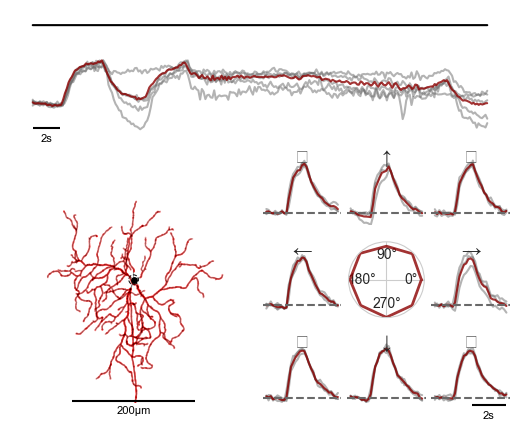

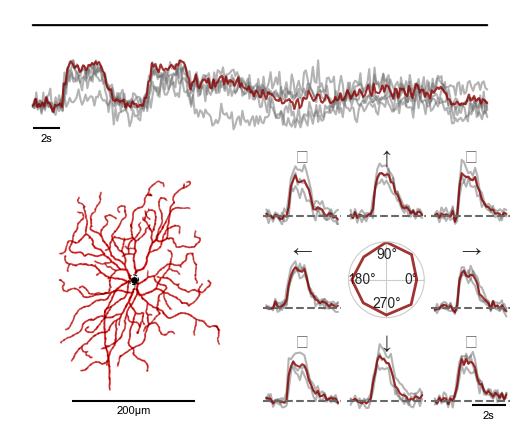

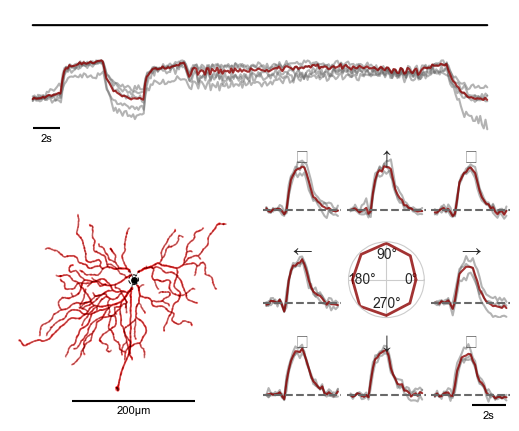

In [35]:
df = add_skels(df_son)

for i, (seg_id, row) in enumerate(df.iterrows()):
    r = i + 1


    
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0.0)
    plt.savefig(os.path.join(fig2_dir, 'sON_examples_'+str(r)+'.png'), dpi=600)
    plt.savefig(os.path.join(fig2_dir, 'sON_examples_'+str(r)+'.svg'), dpi=600)

## PixON

C:\Users\joesterle\github\eulerlab\eyewire2-functional-analysis\.venv\Lib\site-packages\skeliner\plot\vis2d.py:625: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\joesterle\AppData\Local\Temp\ipykernel_10680\2286140382.py:50: UserWarning: Glyph 8598 (\N{NORTH WEST ARROW}) missing from font(s) Arial.
  plt.savefig(os.path.join(fig2_dir, 'pixon_examples_'+str(r)+'.png'), dpi=600)
C:\Users\joesterle\AppData\Local\Temp\ipykernel_10680\2286140382.py:50: UserWarning: Glyph 8599 (\N{NORTH EAST ARROW}) missing from font(s) Arial.
  plt.savefig(os.path.join(fig2_dir, 'pixon_examples_'+str(r)+'.png'), dpi=600)
C:\Users\joesterle\AppData\Local\Temp\ipykernel_10680\2286140382.py:50: UserWarning: Glyph 8601 (\N{SOUTH WEST ARROW}) missing from font(s) Arial.
  plt.savefig(os.path.join(fig2_dir, 'pixon_examples_'+str(r)+'.png'), dpi=600)
C:\Users\joesterle\AppData\Local\Temp\ipykernel_10680\2286140382.py:5

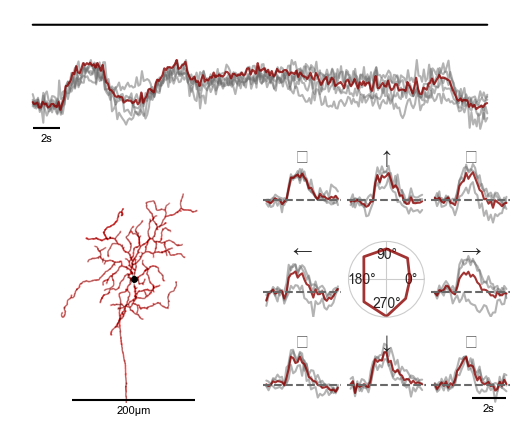

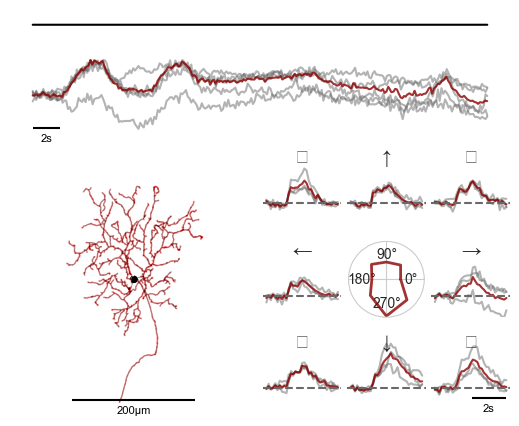

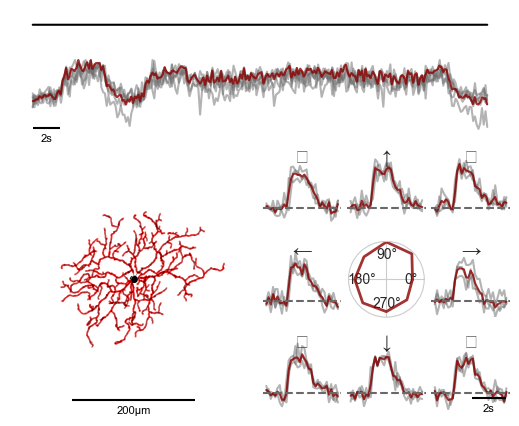

In [36]:
df = add_skels(df_pixon)

for i, (seg_id, row) in enumerate(df.iterrows()):
    r = i + 1

    fig, ax = plt.subplot_mosaic(
        """
        XXXXXX
        AAAAAA
        BBBCDE
        BBBFGH
        BBBIJK
        """,  
        figsize=(5, 4),
        gridspec_kw=dict(
            hspace=0.25, wspace=0.07, height_ratios=[0.4, 1, 1, 1, 1]),)
    
    plot_morph(ax=ax['B'], row=row)
    plot_chirp(ax=ax['A'], row=row)
    plot_bar_dir(ax=ax['G'], row=row)
    ax['G'].set(xlabel=None, ylabel=None, xticks=np.deg2rad([0, 90, 180, 270]), yticks=[], ylim=(0, None))
    
    
    MB_DIRS = (0, 180, 45, 225, 90, 270, 135, 315)  # your data order
    desired_deg = [0, 45, 90, 135, 180, 225, 270, 315]
    dir_idx_order = [MB_DIRS.index(d) for d in desired_deg]
    
    plot_bar_split(ax, row, labels=('C','D','E','F','H','I','J','K'), dir_idx_order=([6, 4, 2, 1, 0, 3, 5, 7]))
    
    gs = ax['G'].get_subplotspec()
    ax['G'].remove()
    ax['G'] = fig.add_subplot(gs, projection='polar')
    plot_bar_dir(ax=ax['G'], row=row)
    ax['G'].set(xlabel=None, ylabel=None, xticks=np.deg2rad([0, 90, 180, 270]), yticks=[], ylim=(0, None))
    
    ax['X'].plot(chirp_stimulus, color='k',lw=1.5)

    # remove axes
    for i in ['A','B','C','D','E','F','H','I','J','K','X']:
        ax[i].set(xlabel=None, ylabel=None, xticks=[], yticks=[])
        ax[i].axis('off')

    # scale bar
    draw_scale_bar(ax['B'], length_data=200, label="200µm", where="lower center", y_frac=0.01)
    draw_scale_bar(ax['A'], length_data=2, label="2s", where="lower left", y_frac=0.06, x_pad_axes=0.045)
    draw_scale_bar(ax['K'], length_data=2, label="2s", where="lower right", y_frac=0.15, x_pad_axes=0.045)
    #ax['B'].set_ylim(70,400)
    
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0.0)
    plt.savefig(os.path.join(fig2_dir, 'pixon_examples_'+str(r)+'.png'), dpi=600)
    plt.savefig(os.path.join(fig2_dir, 'pixon_examples_'+str(r)+'.svg'), dpi=600)

## UHD

C:\Users\joesterle\github\eulerlab\eyewire2-functional-analysis\.venv\Lib\site-packages\skeliner\plot\vis2d.py:625: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\joesterle\AppData\Local\Temp\ipykernel_10680\1025848094.py:50: UserWarning: Glyph 8598 (\N{NORTH WEST ARROW}) missing from font(s) Arial.
  plt.savefig(os.path.join(fig2_dir, 'uhd_examples_'+str(r)+'.png'), dpi=600)
C:\Users\joesterle\AppData\Local\Temp\ipykernel_10680\1025848094.py:50: UserWarning: Glyph 8599 (\N{NORTH EAST ARROW}) missing from font(s) Arial.
  plt.savefig(os.path.join(fig2_dir, 'uhd_examples_'+str(r)+'.png'), dpi=600)
C:\Users\joesterle\AppData\Local\Temp\ipykernel_10680\1025848094.py:50: UserWarning: Glyph 8601 (\N{SOUTH WEST ARROW}) missing from font(s) Arial.
  plt.savefig(os.path.join(fig2_dir, 'uhd_examples_'+str(r)+'.png'), dpi=600)
C:\Users\joesterle\AppData\Local\Temp\ipykernel_10680\1025848094.py:50: Use

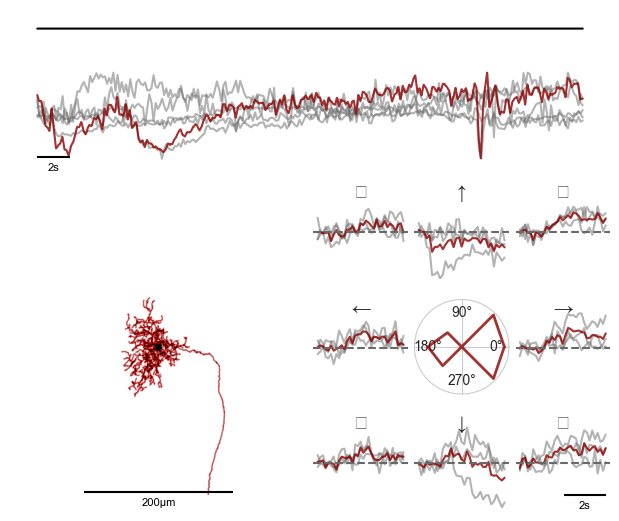

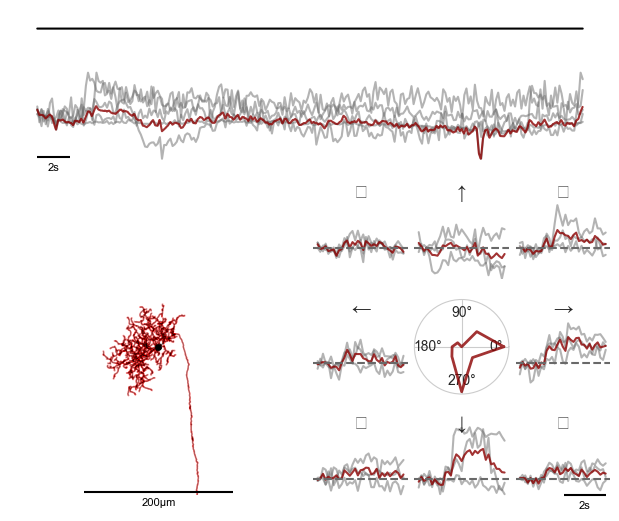

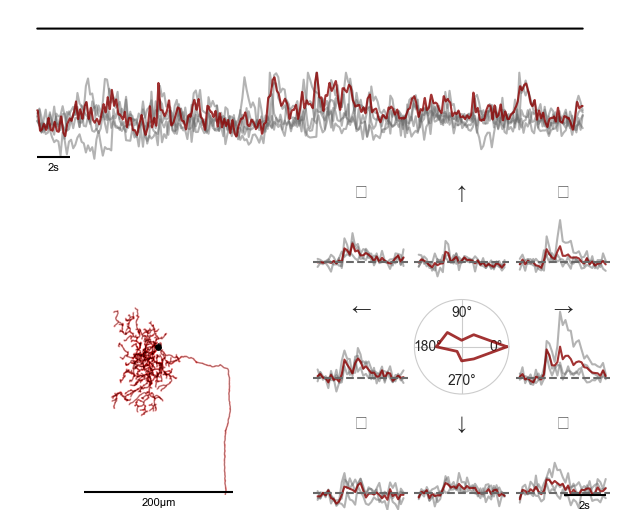

In [37]:
df = add_skels(df_uhd)

for i, (seg_id, row) in enumerate(df.iterrows()):
    r = i + 1

    fig, ax = plt.subplot_mosaic(
        """
        XXXXXX
        AAAAAA
        BBBCDE
        BBBFGH
        BBBIJK
        """,  
        figsize=(6,5),
        gridspec_kw=dict(
            hspace=0.25, wspace=0.07, height_ratios=[0.4, 1, 1, 1, 1]),)
    
    plot_morph(ax=ax['B'], row=row)
    plot_chirp(ax=ax['A'], row=row)
    plot_bar_dir(ax=ax['G'], row=row)
    ax['G'].set(xlabel=None, ylabel=None, xticks=np.deg2rad([0, 90, 180, 270]), yticks=[], ylim=(0, None))
    
    
    MB_DIRS = (0, 180, 45, 225, 90, 270, 135, 315)  # your data order
    desired_deg = [0, 45, 90, 135, 180, 225, 270, 315]
    dir_idx_order = [MB_DIRS.index(d) for d in desired_deg]
    
    plot_bar_split(ax, row, labels=('C','D','E','F','H','I','J','K'), dir_idx_order=([6, 4, 2, 1, 0, 3, 5, 7]))
    
    gs = ax['G'].get_subplotspec()
    ax['G'].remove()
    ax['G'] = fig.add_subplot(gs, projection='polar')
    plot_bar_dir(ax=ax['G'], row=row)
    ax['G'].set(xlabel=None, ylabel=None, xticks=np.deg2rad([0, 90, 180, 270]), yticks=[], ylim=(0, None))
    
    ax['X'].plot(chirp_stimulus, color='k',lw=1.5)

    # remove axes
    for i in ['A','B','C','D','E','F','H','I','J','K','X']:
        ax[i].set(xlabel=None, ylabel=None, xticks=[], yticks=[])
        ax[i].axis('off')

    # scale bar
    draw_scale_bar(ax['B'], length_data=200, label="200µm", where="lower center", y_frac=0.01)
    draw_scale_bar(ax['A'], length_data=2, label="2s", where="lower left", y_frac=0.06, x_pad_axes=0.045)
    draw_scale_bar(ax['K'], length_data=2, label="2s", where="lower right", y_frac=0.15, x_pad_axes=0.045)
    #ax['B'].set_ylim(70,400)
    
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0.0)
    plt.savefig(os.path.join(fig2_dir, 'uhd_examples_'+str(r)+'.png'), dpi=600)
    plt.savefig(os.path.join(fig2_dir, 'uhd_examples_'+str(r)+'.svg'), dpi=600)

# Example cell

C:\Users\joesterle\github\eulerlab\eyewire2-functional-analysis\.venv\Lib\site-packages\skeliner\plot\vis2d.py:625: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\joesterle\AppData\Local\Temp\ipykernel_10680\947669623.py:50: UserWarning: Glyph 8598 (\N{NORTH WEST ARROW}) missing from font(s) Arial.
  plt.savefig(os.path.join(fig2_dir, 'example_'+str(r)+'.png'), dpi=600)
C:\Users\joesterle\AppData\Local\Temp\ipykernel_10680\947669623.py:50: UserWarning: Glyph 8599 (\N{NORTH EAST ARROW}) missing from font(s) Arial.
  plt.savefig(os.path.join(fig2_dir, 'example_'+str(r)+'.png'), dpi=600)
C:\Users\joesterle\AppData\Local\Temp\ipykernel_10680\947669623.py:50: UserWarning: Glyph 8601 (\N{SOUTH WEST ARROW}) missing from font(s) Arial.
  plt.savefig(os.path.join(fig2_dir, 'example_'+str(r)+'.png'), dpi=600)
C:\Users\joesterle\AppData\Local\Temp\ipykernel_10680\947669623.py:50: UserWarning: Glyph 860

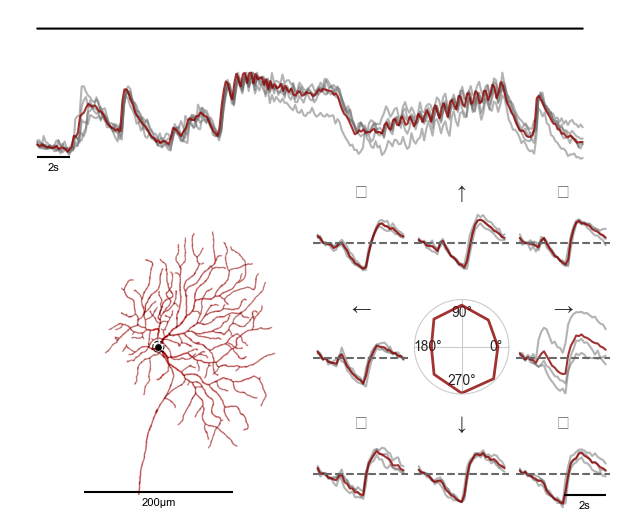

In [39]:
df = add_skels(df_example)

for i, (seg_id, row) in enumerate(df.iterrows()):
    r = i + 1

    fig, ax = plt.subplot_mosaic(
        """
        XXXXXX
        AAAAAA
        BBBCDE
        BBBFGH
        BBBIJK
        """,
        figsize=(6,5),
        gridspec_kw=dict(
            hspace=0.25, wspace=0.07, height_ratios=[0.4, 1, 1, 1, 1]),)

    plot_morph(ax=ax['B'], row=row)
    plot_chirp(ax=ax['A'], row=row)
    plot_bar_dir(ax=ax['G'], row=row)
    ax['G'].set(xlabel=None, ylabel=None, xticks=np.deg2rad([0, 90, 180, 270]), yticks=[], ylim=(0, None))


    MB_DIRS = (0, 180, 45, 225, 90, 270, 135, 315)  # your data order
    desired_deg = [0, 45, 90, 135, 180, 225, 270, 315]
    dir_idx_order = [MB_DIRS.index(d) for d in desired_deg]

    plot_bar_split(ax, row, labels=('C','D','E','F','H','I','J','K'), dir_idx_order=([6, 4, 2, 1, 0, 3, 5, 7]))

    gs = ax['G'].get_subplotspec()
    ax['G'].remove()
    ax['G'] = fig.add_subplot(gs, projection='polar')
    plot_bar_dir(ax=ax['G'], row=row)
    ax['G'].set(xlabel=None, ylabel=None, xticks=np.deg2rad([0, 90, 180, 270]), yticks=[], ylim=(0, None))

    ax['X'].plot(chirp_stimulus, color='k',lw=1.5)

    # remove axes
    for i in ['A','B','C','D','E','F','H','I','J','K','X']:
        ax[i].set(xlabel=None, ylabel=None, xticks=[], yticks=[])
        ax[i].axis('off')

    # scale bar
    draw_scale_bar(ax['B'], length_data=200, label="200µm", where="lower center", y_frac=0.01)
    draw_scale_bar(ax['A'], length_data=2, label="2s", where="lower left", y_frac=0.06, x_pad_axes=0.045)
    draw_scale_bar(ax['K'], length_data=2, label="2s", where="lower right", y_frac=0.15, x_pad_axes=0.045)
    #ax['B'].set_ylim(70,400)

    plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0.0)
    plt.savefig(os.path.join(fig2_dir, 'example_'+str(r)+'.png'), dpi=600)
    plt.savefig(os.path.join(fig2_dir, 'example_'+str(r)+'.svg'), dpi=600)